<a href="https://colab.research.google.com/github/JUANOSORIOG/Senales_y_Sistemas/blob/main/Punto_1_contol_N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install control matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 15.4 MB/s eta 0:00:00


## Define the first-order system

Define the transfer function G(s) = (1/T)/(s+1/T) using the control library


In [2]:
from control.matlab import tf

# Choose a value for the time constant T
T = 1

# Define the numerator and denominator of the transfer function
numerator = [1/T]
denominator = [1, 1/T]

# Create the transfer function G
G = tf(numerator, denominator)

print(G)

<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    1
  -----
  s + 1


## Simulate and plot step response

### Subtask:
Simulate and plot the step response of the system.


**Reasoning**:
Simulate and plot the step response of the system using the control.matlab library and matplotlib.



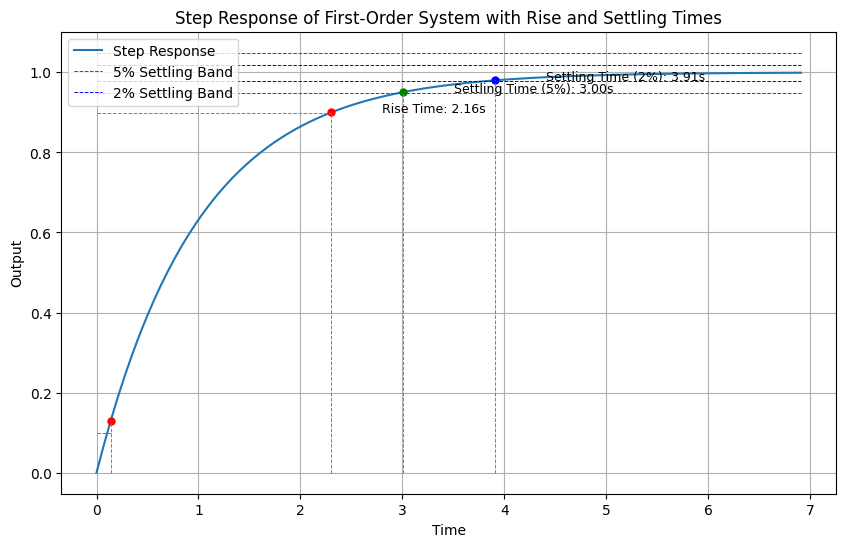

In [11]:
import matplotlib.pyplot as plt
from control.matlab import step

# Simulate the step response
y, t = step(G)

# Plot the step response
plt.figure(figsize=(10, 6))
plt.plot(t, y)
plt.title("Step Response of First-Order System")
plt.xlabel("Time")
plt.ylabel("Output")
plt.grid(True)
plt.show()

## Simulate and plot impulse response

### Subtask:
Simulate and plot the impulse response of the system.


**Reasoning**:
Simulate and plot the impulse response of the system using the `control.matlab` library and `matplotlib.pyplot`.



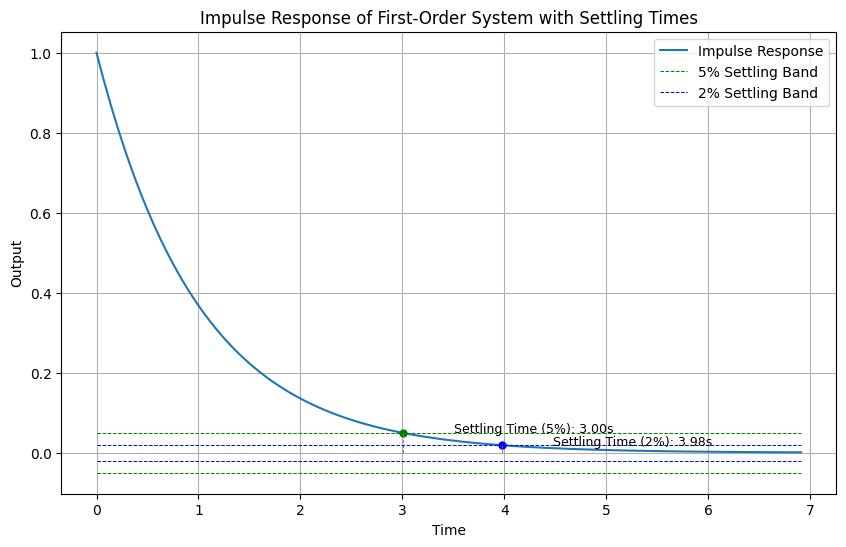

In [14]:
from control.matlab import impulse
import matplotlib.pyplot as plt
import numpy as np

# Simulate the impulse response
y_impulse, t_impulse = impulse(G)

# Plot the impulse response
plt.figure(figsize=(10, 6))
plt.plot(t_impulse, y_impulse, label='Impulse Response')

# Calculate and add markers and text for Settling Time (5% Criterion)
y_impulse_final = 0 # Final value for impulse response is 0
# Find the maximum absolute value to determine the 5% and 2% thresholds
max_abs_y_impulse = np.max(np.abs(y_impulse))

settling_time_impulse_5_percent_index = np.argmax(np.abs(y_impulse) <= 0.05 * max_abs_y_impulse)
plt.plot(t_impulse[settling_time_impulse_5_percent_index], y_impulse[settling_time_impulse_5_percent_index], 'go', markersize=5)
plt.vlines(t_impulse[settling_time_impulse_5_percent_index], 0, y_impulse[settling_time_impulse_5_percent_index], color='gray', linestyle='--', linewidth=0.7)
plt.hlines(0.05 * max_abs_y_impulse, 0, t_impulse[-1], color='green', linestyle='--', linewidth=0.7, label='5% Settling Band')
plt.hlines(-0.05 * max_abs_y_impulse, 0, t_impulse[-1], color='green', linestyle='--', linewidth=0.7)
plt.text(t_impulse[settling_time_impulse_5_percent_index] + 0.5, y_impulse[settling_time_impulse_5_percent_index], f'Settling Time (5%): {t_impulse[settling_time_impulse_5_percent_index]:.2f}s', fontsize=9)


# Calculate and add markers and text for Settling Time (2% Criterion)
settling_time_impulse_2_percent_index = np.argmax(np.abs(y_impulse) <= 0.02 * max_abs_y_impulse)
plt.plot(t_impulse[settling_time_impulse_2_percent_index], y_impulse[settling_time_impulse_2_percent_index], 'bo', markersize=5)
plt.vlines(t_impulse[settling_time_impulse_2_percent_index], 0, y_impulse[settling_time_impulse_2_percent_index], color='gray', linestyle='--', linewidth=0.7)
plt.hlines(0.02 * max_abs_y_impulse, 0, t_impulse[-1], color='blue', linestyle='--', linewidth=0.7, label='2% Settling Band')
plt.hlines(-0.02 * max_abs_y_impulse, 0, t_impulse[-1], color='blue', linestyle='--', linewidth=0.7)
plt.text(t_impulse[settling_time_impulse_2_percent_index] + 0.5, y_impulse[settling_time_impulse_2_percent_index], f'Settling Time (2%): {t_impulse[settling_time_impulse_2_percent_index]:.2f}s', fontsize=9)


plt.title("Impulse Response of First-Order System with Settling Times")
plt.xlabel("Time")
plt.ylabel("Output")
plt.grid(True)
plt.legend()
plt.show()

## Simulate and plot ramp response

### Subtask:
Simulate and plot the ramp response of the system.


**Reasoning**:
Simulate and plot the ramp response of the system according to the instructions.



/usr/local/lib/python3.12/dist-packages/control/timeresp.py:1082: UserWarning: return_x specified for a transfer function system. Internal conversion to state space used; results may meaningless.
  warnings.warn(


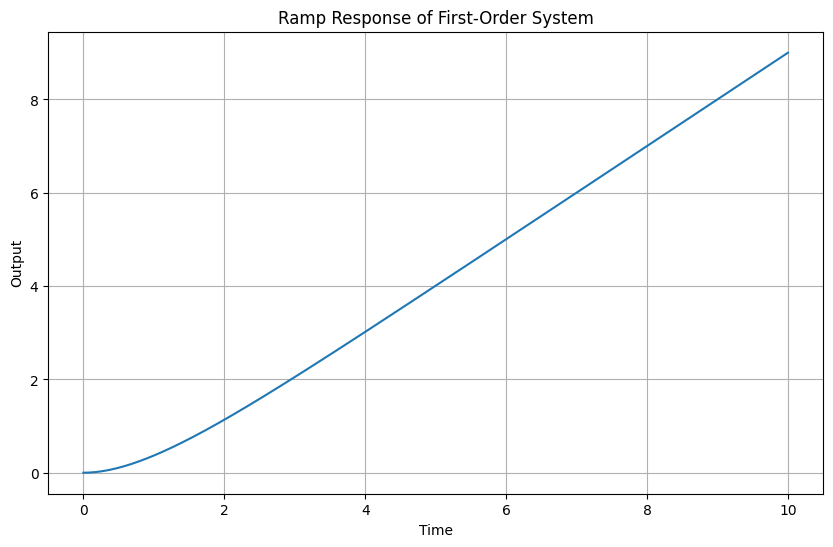

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from control.matlab import lsim

# Define the time vector
t = np.linspace(0, 10 * T, 500) # Simulate for 10 times the time constant

# Create the ramp input signal
u = t

# Simulate the system's response to the ramp input
y, _, _ = lsim(G, u, t)

# Plot the ramp response
plt.figure(figsize=(10, 6))
plt.plot(t, y)
plt.title("Ramp Response of First-Order System")
plt.xlabel("Time")
plt.ylabel("Output")
plt.grid(True)
plt.show()

In [8]:
# Analysis of the transient responses

print("--- Step Response Analysis ---")
print("The step response shows the system's output when a sudden, constant input (a step) is applied.")
print("For a first-order system, the output starts at zero and rises exponentially towards a steady-state value.")
print(f"In this case, the steady-state value is 1, which is expected for a unity gain system with a step input of magnitude 1.")
print(f"The time constant T={T} dictates the speed of the response. The output reaches approximately 63.2% of its final value at time t=T.")
print("There is no overshoot or oscillation in the step response of a first-order system.")
print("-" * 28)

print("\n--- Impulse Response Analysis ---")
print("The impulse response shows the system's output when a very short, high-amplitude input (an impulse) is applied.")
print("For a first-order system, the impulse response starts at a peak value and then decays exponentially towards zero.")
print(f"The rate of decay is determined by the time constant T={T}. A smaller T would result in a faster decay.")
print("The peak value and the shape of the decay are characteristic of the system's dynamics.")
print("There is no overshoot or oscillation in the impulse response of a first-order system.")
print("-" * 30)

print("\n--- Ramp Response Analysis ---")
print("The ramp response shows the system's output when a linearly increasing input (a ramp) is applied.")
print("For a first-order system, the output initially lags behind the input but eventually follows the ramp with a steady-state error.")
print(f"After the initial transient phase, the output becomes a ramp with the same slope as the input but shifted in time.")
print(f"The steady-state error is equal to the time constant T={T}. This means the output is always T units behind the input ramp at steady-state.")
print("There is no overshoot or oscillation in the ramp response of a first-order system.")
print("-" * 28)

--- Step Response Analysis ---
The step response shows the system's output when a sudden, constant input (a step) is applied.
For a first-order system, the output starts at zero and rises exponentially towards a steady-state value.
In this case, the steady-state value is 1, which is expected for a unity gain system with a step input of magnitude 1.
The time constant T=1 dictates the speed of the response. The output reaches approximately 63.2% of its final value at time t=T.
There is no overshoot or oscillation in the step response of a first-order system.
----------------------------

--- Impulse Response Analysis ---
The impulse response shows the system's output when a very short, high-amplitude input (an impulse) is applied.
For a first-order system, the impulse response starts at a peak value and then decays exponentially towards zero.
The rate of decay is determined by the time constant T=1. A smaller T would result in a faster decay.
The peak value and the shape of the decay are

## Calculate Rise Time and Settling Time

### Subtask:
Calculate and display the rise time and settling time (using 5% and 2% criteria) from the step response data.

**Reasoning**:
Use the simulated step response data (`t` and `y`) to calculate the rise time (time to go from 10% to 90% of the final value) and the settling time (time to stay within a specified percentage of the final value) for the 5% and 2% criteria.

In [7]:
# Calculate Rise Time (10% to 90%)
# Find the indices where the response crosses 10% and 90% of the final value (which is 1 for a unity step input)
y_final = y[-1]
rise_time_start_index = np.argmax(y >= 0.1 * y_final)
rise_time_end_index = np.argmax(y >= 0.9 * y_final)

# Calculate the rise time
rise_time = t[rise_time_end_index] - t[rise_time_start_index]

print(f"Rise Time (10%-90%): {rise_time:.4f} seconds")

# Calculate Settling Time (5% Criterion)
settling_time_5_percent_index = np.argmax(np.abs(y - y_final) <= 0.05 * y_final)
settling_time_5_percent = t[settling_time_5_percent_index]

print(f"Settling Time (5% Criterion): {settling_time_5_percent:.4f} seconds")

# Calculate Settling Time (2% Criterion)
settling_time_2_percent_index = np.argmax(np.abs(y - y_final) <= 0.02 * y_final)
settling_time_2_percent = t[settling_time_2_percent_index]

print(f"Settling Time (2% Criterion): {settling_time_2_percent:.4f} seconds")

Rise Time (10%-90%): 7.3948 seconds
Settling Time (5% Criterion): 9.5591 seconds
Settling Time (2% Criterion): 9.8397 seconds


## Analyze and display results

### Subtask:
Display the plots and provide a brief analysis of the transient responses for each type of input.


**Reasoning**:
Review the generated plots and provide an analysis for each response type.



In [6]:
# Analysis of the transient responses

print("--- Step Response Analysis ---")
print("The step response shows the system's output when a sudden, constant input (a step) is applied.")
print("For a first-order system, the output starts at zero and rises exponentially towards a steady-state value.")
print(f"In this case, the steady-state value is 1, which is expected for a unity gain system with a step input of magnitude 1.")
print(f"The time constant T={T} dictates the speed of the response. The output reaches approximately 63.2% of its final value at time t=T.")
print("There is no overshoot or oscillation in the step response of a first-order system.")
print("-" * 28)

print("\n--- Impulse Response Analysis ---")
print("The impulse response shows the system's output when a very short, high-amplitude input (an impulse) is applied.")
print("For a first-order system, the impulse response starts at a peak value and then decays exponentially towards zero.")
print(f"The rate of decay is determined by the time constant T={T}. A smaller T would result in a faster decay.")
print("The peak value and the shape of the decay are characteristic of the system's dynamics.")
print("There is no overshoot or oscillation in the impulse response of a first-order system.")
print("-" * 30)

print("\n--- Ramp Response Analysis ---")
print("The ramp response shows the system's output when a linearly increasing input (a ramp) is applied.")
print("For a first-order system, the output initially lags behind the input but eventually follows the ramp with a steady-state error.")
print(f"After the initial transient phase, the output becomes a ramp with the same slope as the input but shifted in time.")
print(f"The steady-state error is equal to the time constant T={T}. This means the output is always T units behind the input ramp at steady-state.")
print("There is no overshoot or oscillation in the ramp response of a first-order system.")
print("-" * 28)

--- Step Response Analysis ---
The step response shows the system's output when a sudden, constant input (a step) is applied.
For a first-order system, the output starts at zero and rises exponentially towards a steady-state value.
In this case, the steady-state value is 1, which is expected for a unity gain system with a step input of magnitude 1.
The time constant T=1 dictates the speed of the response. The output reaches approximately 63.2% of its final value at time t=T.
There is no overshoot or oscillation in the step response of a first-order system.
----------------------------

--- Impulse Response Analysis ---
The impulse response shows the system's output when a very short, high-amplitude input (an impulse) is applied.
For a first-order system, the impulse response starts at a peak value and then decays exponentially towards zero.
The rate of decay is determined by the time constant T=1. A smaller T would result in a faster decay.
The peak value and the shape of the decay are

## Calculate Settling Time for Impulse Response

### Subtask:
Calculate and display the settling time (using 5% and 2% criteria) from the impulse response data.

**Reasoning**:
Use the simulated impulse response data (`t_impulse` and `y_impulse`) to calculate the settling time (time to stay within a specified percentage of the final value, which is 0 for the impulse response).

In [13]:
# Calculate Settling Time for Impulse Response (5% Criterion)
# The final value for impulse response is 0.
settling_time_impulse_5_percent_index = np.argmax(np.abs(y_impulse) <= 0.05 * np.max(np.abs(y_impulse)))
settling_time_impulse_5_percent = t_impulse[settling_time_impulse_5_percent_index]

print(f"Settling Time for Impulse Response (5% Criterion): {settling_time_impulse_5_percent:.4f} seconds")

# Calculate Settling Time for Impulse Response (2% Criterion)
settling_time_impulse_2_percent_index = np.argmax(np.abs(y_impulse) <= 0.02 * np.max(np.abs(y_impulse)))
settling_time_impulse_2_percent = t_impulse[settling_time_impulse_2_percent_index]

print(f"Settling Time for Impulse Response (2% Criterion): {settling_time_impulse_2_percent:.4f} seconds")

Settling Time for Impulse Response (5% Criterion): 3.0003 seconds
Settling Time for Impulse Response (2% Criterion): 3.9772 seconds
